# Impedance Control
With OSC, you're telling the robot to go to an exact pose. It fights as hard as it can to get there and stay there.  
With impedance control, instead of commanding a **dynamic relationship** between the robot and its environment. 


Specifically, you're making the end-effector behave as a mass-spring-damper system:  
```
F = Kp (x_des - x) - Kd*dx
```

In OSC, you crank Kp high because you want precise position tracking. In impedance control, `Kp` itself becomes the thing you are designing.  
- High Kp -> stiff, position-tracking behaviour. Robot holds its ground against distrurbances.
- Low Kp -> compliant behaviour. The robot yields to external forces. 

This is why it is called impedance - you're controlling how much the robot "impedes" motion caused by external forces.


In [1]:
import mujoco
import mediapy as media
import matplotlib.pyplot as plt
import numpy as np
from robot_descriptions import panda_mj_description

HEIGHT = 480
WIDTH = 480
DURATION = 3.8  # (seconds)
FRAMERATE = 60  # (Hz)

# Panda torque limits: 87 Nm for joints 1-4, 12 Nm for joints 5-7
TORQUE_LIMITS = [87, 87, 87, 87, 12, 12, 12]

# Load the model and override arm actuators to direct torque control.
# The Panda MJCF ships with position-controlled actuators (biastype=1) that
# have built-in PD gains (e.g. Kp=4500, Kd=450), meaning ctrl is interpreted
# as a target position. For manual PD control we need ctrl = raw torque.
model = mujoco.MjModel.from_xml_path(panda_mj_description.MJCF_PATH)
for i in range(7):  # first 7 actuators = arm joints
    model.actuator_gainprm[i, 0] = 1.0      # gain * ctrl = 1 * ctrl
    model.actuator_biastype[i] = 0           # no bias term
    model.actuator_biasprm[i, :] = 0.0
    # ctrlrange was set to joint position limits (e.g. [-2.89, 2.89]) which
    # would clamp torques to ~3 Nm. Set to actual torque limits.
    model.actuator_ctrlrange[i] = [-TORQUE_LIMITS[i], TORQUE_LIMITS[i]]
    model.actuator_forcerange[i] = [-TORQUE_LIMITS[i], TORQUE_LIMITS[i]]
data = mujoco.MjData(model)


In [2]:
# anisotropic stiffness
Kp = np.diag([100, 100, 1000, 1000, 1000, 1000])
Kp

array([[ 100,    0,    0,    0,    0,    0],
       [   0,  100,    0,    0,    0,    0],
       [   0,    0, 1000,    0,    0,    0],
       [   0,    0,    0, 1000,    0,    0],
       [   0,    0,    0,    0, 1000,    0],
       [   0,    0,    0,    0,    0, 1000]])

In [3]:
def rot_x(deg):
    a = np.radians(deg)
    return np.array([[1, 0, 0], [0, np.cos(a), -np.sin(a)], [0, np.sin(a), np.cos(a)]])
R_down = rot_x(180)

des_pos = (np.array([0.3, -0.1, 0.7]), R_down)

data = mujoco.MjData(model)
mujoco.mj_forward(model, data)
ee_body_id = model.body("link7").id
Kd = 2 * np.sqrt(Kp)

frames = []
with mujoco.Renderer(model) as renderer:
    while data.time < DURATION:
        ee_pos = data.body(ee_body_id).xpos

        jacp = np.zeros((3, model.nv))
        jacr = np.zeros((3, model.nv))
        mujoco.mj_jacBody(model, data, jacp, jacr, ee_body_id)


        xvel = jacp @ data.qvel
        F_pos = Kp[:3, :3] @ (des_pos[0] - ee_pos) - Kd[:3, :3] @ xvel

        # Orientation
        R = data.body(ee_body_id).xmat.reshape(3, 3)
        R_err = des_pos[1] @ R.T
        R_err_quat = np.zeros(4)
        mujoco.mju_mat2Quat(R_err_quat, R_err.flatten())
        R_err_aa = np.zeros(3)
        mujoco.mju_quat2Vel(R_err_aa, R_err_quat, 1.0)
        rvel = jacr @ data.qvel
        F_ori = Kp[3:, 3:] @ R_err_aa - Kd[3:,3:] @ rvel

        # Torque
        F_task = np.concatenate([F_pos, F_ori])
        jac = np.concatenate([jacp, jacr])
        tau = jac.T @ F_task

        data.ctrl[:7] = tau[:7] + data.qfrc_bias[:7]
        mujoco.mj_step(model, data)

        if len(frames) < data.time * FRAMERATE:
            renderer.update_scene(data)
            frames.append(renderer.render())

media.show_video(frames, fps=FRAMERATE)

libdecor-gtk-WARNING: Failed to initialize GTK
Failed to load plugin 'libdecor-gtk.so': failed to init


This browser does not support the video tag.


Since I set the z stiffness high, it reaches correct z quickly but takes time to reach desired x, y

This browser does not support the video tag.


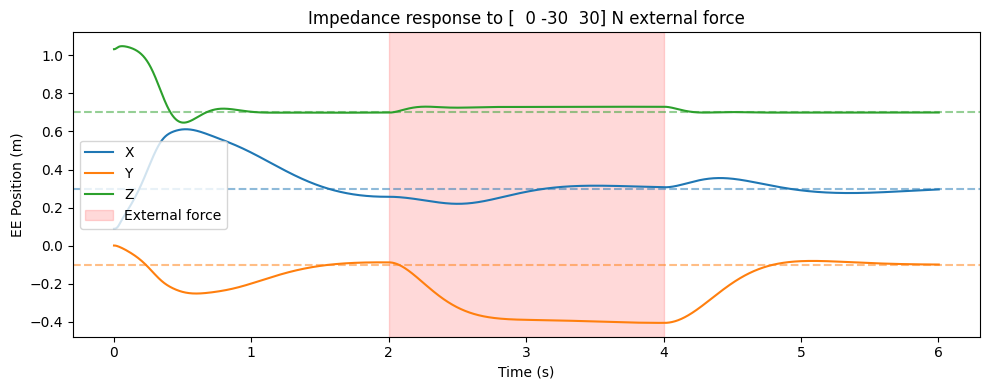

In [4]:
DURATION_EXT = 6.0
FORCE_START = 2.0  # when to apply force (seconds)
FORCE_END = 4.0    # when to stop force
EXT_FORCE = np.array([0, -30, 30])  # 30N push in Y direction

model.geom_rgba[:, 3] = 0.3

data = mujoco.MjData(model)
mujoco.mj_forward(model, data)
ee_body_id = model.body("link7").id

frames = []
ee_positions = []
times = []

with mujoco.Renderer(model) as renderer:
    while data.time < DURATION_EXT:
        ee_pos = data.body(ee_body_id).xpos.copy()

        jacp = np.zeros((3, model.nv))
        jacr = np.zeros((3, model.nv))
        mujoco.mj_jacBody(model, data, jacp, jacr, ee_body_id)

        xvel = jacp @ data.qvel
        F_pos = Kp[:3, :3] @ (des_pos[0] - ee_pos) - Kd[:3, :3] @ xvel

        R = data.body(ee_body_id).xmat.reshape(3, 3)
        R_err = des_pos[1] @ R.T
        R_err_quat = np.zeros(4)
        mujoco.mju_mat2Quat(R_err_quat, R_err.flatten())
        R_err_aa = np.zeros(3)
        mujoco.mju_quat2Vel(R_err_aa, R_err_quat, 1.0)
        rvel = jacr @ data.qvel
        F_ori = Kp[3:, 3:] @ R_err_aa - Kd[3:, 3:] @ rvel

        F_task = np.concatenate([F_pos, F_ori])
        jac = np.concatenate([jacp, jacr])
        tau = jac.T @ F_task

        data.ctrl[:7] = tau[:7] + data.qfrc_bias[:7]

        # Apply external force to EE body during [FORCE_START, FORCE_END]
        if FORCE_START <= data.time < FORCE_END:
            data.xfrc_applied[ee_body_id, :3] = EXT_FORCE
        else:
            data.xfrc_applied[ee_body_id, :3] = 0

        mujoco.mj_step(model, data)

        ee_positions.append(ee_pos)
        times.append(data.time)

        if len(frames) < data.time * FRAMERATE:
            renderer.update_scene(data)
            if FORCE_START <= data.time < FORCE_END:
                colors = [[1,0,0,1], [0,1,0,1], [0,0,1,1]]  # RGB = XYZ
                force_scale = 0.005
                for axis in range(3):
                    if abs(EXT_FORCE[axis]) > 0:
                        geom = renderer.scene.geoms[renderer.scene.ngeom]
                        direction = np.zeros(3)
                        direction[axis] = EXT_FORCE[axis]
                        end = ee_pos + direction * force_scale
                        mujoco.mjv_connector(geom, mujoco.mjtGeom.mjGEOM_CAPSULE, 0.008, ee_pos, end)
                        geom.rgba = np.array(colors[axis], dtype=np.float32)
                        renderer.scene.ngeom += 1
            frames.append(renderer.render().copy())

media.show_video(frames, fps=FRAMERATE)

ee_positions = np.array(ee_positions)
times = np.array(times)

fig, ax = plt.subplots(figsize=(10, 4))
for i, label in enumerate(["X", "Y", "Z"]):
    ax.plot(times, ee_positions[:, i], label=label)
    ax.axhline(des_pos[0][i], color=f"C{i}", linestyle="--", alpha=0.5)
ax.axvspan(FORCE_START, FORCE_END, alpha=0.15, color="red", label="External force")
ax.set_xlabel("Time (s)")
ax.set_ylabel("EE Position (m)")
ax.set_title(f"Impedance response to {EXT_FORCE} N external force")
ax.legend()
plt.tight_layout()
plt.show()

## Stiffness Switching

In [12]:
Kp_stiff = np.diag([100, 100, 1000, 1000, 1000, 1000])
Kp_compliant = np.diag([100, 100, 100, 100, 100, 100])
switching_height = 0.6

This browser does not support the video tag.


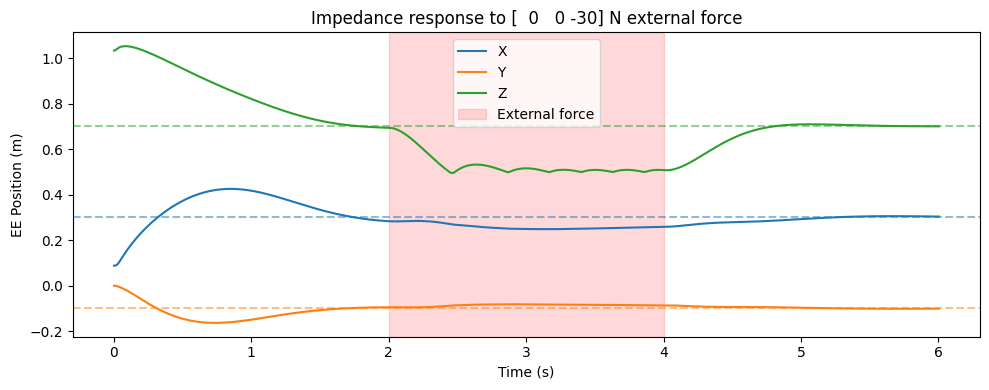

In [14]:
DURATION_EXT = 6.0
FORCE_START = 2.0  # when to apply force (seconds)
FORCE_END = 4.0    # when to stop force
EXT_FORCE = np.array([0, 0, -30])  # 30N push in Y direction

data = mujoco.MjData(model)
mujoco.mj_forward(model, data)
ee_body_id = model.body("link7").id

frames = []
ee_positions = []
times = []

with mujoco.Renderer(model) as renderer:
    while data.time < DURATION_EXT:
        ee_pos = data.body(ee_body_id).xpos.copy()

        if ee_pos[2] > 0.5:
            Kp_active = Kp_compliant
        else:
            Kp_active = Kp_stiff

        Kd = 2 * np.sqrt(Kp_active)

        jacp = np.zeros((3, model.nv))
        jacr = np.zeros((3, model.nv))
        mujoco.mj_jacBody(model, data, jacp, jacr, ee_body_id)

        xvel = jacp @ data.qvel
        F_pos = Kp_active[:3, :3] @ (des_pos[0] - ee_pos) - Kd[:3, :3] @ xvel

        R = data.body(ee_body_id).xmat.reshape(3, 3)
        R_err = des_pos[1] @ R.T
        R_err_quat = np.zeros(4)
        mujoco.mju_mat2Quat(R_err_quat, R_err.flatten())
        R_err_aa = np.zeros(3)
        mujoco.mju_quat2Vel(R_err_aa, R_err_quat, 1.0)
        rvel = jacr @ data.qvel
        F_ori = Kp_active[3:, 3:] @ R_err_aa - Kd[3:, 3:] @ rvel

        F_task = np.concatenate([F_pos, F_ori])
        jac = np.concatenate([jacp, jacr])
        tau = jac.T @ F_task

        data.ctrl[:7] = tau[:7] + data.qfrc_bias[:7]

        # Apply external force to EE body during [FORCE_START, FORCE_END]
        if FORCE_START <= data.time < FORCE_END:
            data.xfrc_applied[ee_body_id, :3] = EXT_FORCE
        else:
            data.xfrc_applied[ee_body_id, :3] = 0

        mujoco.mj_step(model, data)

        ee_positions.append(ee_pos)
        times.append(data.time)

        if len(frames) < data.time * FRAMERATE:
            renderer.update_scene(data)
            if FORCE_START <= data.time < FORCE_END:
                colors = [[1,0,0,1], [0,1,0,1], [0,0,1,1]]  # RGB = XYZ
                force_scale = 0.005
                for axis in range(3):
                    if abs(EXT_FORCE[axis]) > 0:
                        geom = renderer.scene.geoms[renderer.scene.ngeom]
                        direction = np.zeros(3)
                        direction[axis] = EXT_FORCE[axis]
                        end = ee_pos + direction * force_scale
                        mujoco.mjv_connector(geom, mujoco.mjtGeom.mjGEOM_CAPSULE, 0.008, ee_pos, end)
                        geom.rgba = np.array(colors[axis], dtype=np.float32)
                        renderer.scene.ngeom += 1

            frames.append(renderer.render().copy())

media.show_video(frames, fps=FRAMERATE)

ee_positions = np.array(ee_positions)
times = np.array(times)

fig, ax = plt.subplots(figsize=(10, 4))
for i, label in enumerate(["X", "Y", "Z"]):
    ax.plot(times, ee_positions[:, i], label=label)
    ax.axhline(des_pos[0][i], color=f"C{i}", linestyle="--", alpha=0.5)
ax.axvspan(FORCE_START, FORCE_END, alpha=0.15, color="red", label="External force")
ax.set_xlabel("Time (s)")
ax.set_ylabel("EE Position (m)")
ax.set_title(f"Impedance response to {EXT_FORCE} N external force")
ax.legend()
plt.tight_layout()
plt.show()